# Using Remote Sensing to Investigate Location of Industrial Development

**Team**: Ziyi Guo and Neve Zhang

**Course**: MUSA 650 Geospatial Machine Learning in Remote Sensing

**Instructor**: Guray Erus, PhD

*Disclaimer*: We consulted the following AI tool to revise codes for this project.
- OpenAI. (2025). ChatGPT (May 1 version) [Large language model]. https://chat.openai.com/chat.

## Project Introduction

**Context**

As a common asset to many metropolitans nowadays, indsutrial buildings may be viewed both as an opportunity but also an eye sore. On the one hand, they create vast employment opportunities and support critical manufacturing industries; on the other, however, industrial buildings, especially legacy establishments, continue to be major sources of pollution and GHG emissions. Due to their traditionally gigantic physicality, the placement of industrial buildings are also entangled with concerns surrounding vacancy, siting economies, and at times, politics. For instance, a [study](https://publichealth.gwu.edu/warehousing-industry-increases-health-harming-pollutants) by the George Washington University found that 20% of warehouses nationwide are concentrated in 10 counties: Los Angeles, Harris, Cook, Miami-Dade, Maricopa, San Bernardino, Orange, Dallas, Alameda, and Cuyahoga, reflecting a clear trend of spatial clustering of these industrial assets as well as their effects.

These ideas and concerns prompted us to frame our task as "Using Remote Sensing to Investigate Location of Industrial Development." In particular, leveraging high-resolution satellite data like imageery from the National Agriculture Imagery Program (NAIP) (1 meter resolution, with "R", "G", "B", and Infrared "N" bands) allows us to predict and detect for industrial developments at the building footprint level. This is an advanced approach as compared to traditional measurements that measures industrial distribution using zoning or land use data, as we are able to capture what is exactly happening on the ground rather than on the paper.

The area of interest (AOI) selected for this project is an approx 8 x 10 km region located south of Downtown Los Angeles, in the area spanning across W Rancho Dominguez, Compton, and Carson. The area features a mixture of suburban residential neighborhoods, amenities like the California State University, Dominguez Hills and the Victoria Golf Course, as well as several unincorporated areas featuring heavy industrial developments. We have selected the region for a large amount of industrial observations it observe, as well as the relatively diverse built typologies allowing us to perform cross sectional comparisons.

**Methodology**

The project makes two attempts at detecting and classifying industrial buildings:

Approach 1: As a more computational efficient power suited to local planning purposes, the project leverages the application of the GeoDeep package and its segmentation models to perform preliminary segmenation of building footprints, then deploys shape detection to predict for industrial buildings in our selected region. While our analysis indicates that this approach is challenged with spatial variations, it produces several takeaways:

- Our approach yields a moderate prediction and detection performance for industrial buildings at a multi-neighborhood scale region

- Our approach drafts a sample work pipeline for using the GeoDeep package

- Our approach demonstrates the usability and limitations of GeoDeep package for specific building typology detection

Approach 2: To improve our prediction outcomes beyond a GeoDeep + Shape Detection method, we leveraged a traditional deep learning method by tiling NAIP images, and using samples created to predict from all bands in each 512 x 512 NAIP tile using a U-Net architecture. This approach has yielded significantly improved results as compared to Approach 1.

**Outcomes**

As a useful case study, our project demonstrates the feasibility of deploying varied deep-learning tools to perform localized industrial building footprints detection, at each's own challenges and limitations. We welcome interested researchers and planners to reach out to us regarding any part of our project and would be willing to seeing the methodology being applied to other study regions.

**References**

- [GeoDeep Documentation](https://github.com/uav4geo/GeoDeep) (GeoDeep is lightweight Python library for AI object detection and semantic segmentation in geospatial rasters or GeoTIFFs. The libarary offers several pre-trained [ONNX models](https://huggingface.co/datasets/UAV4GEO/GeoDeep-Models) useful for object detection and building / road segmentation. Specifically, the building segmentation tool is trained on the [RampDataset](https://cmr.earthdata.nasa.gov/search/concepts/C2781412367-MLHUB.html) at 50cm resolution. As a result, we have tested and found out that the tool cannot be used to segment low-resolution images such as Landsat-8.)

- [NAIP Imagery](https://naip-usdaonline.hub.arcgis.com/), retrieved from [Google Earth Engine](https://earthengine.google.com/)

- [Open Street Map Labels](https://www.openstreetmap.org/), retrieved using [OSMnx](https://osmnx.readthedocs.io/en/stable/) package in Python

- [U-Net documentation](https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/)

**Data**

Images used for this project can be accessed at [Data](https://drive.google.com/drive/folders/18ZvCgTMg2GrmmVmF9iW4TZB37O_7-e_Y?usp=sharing)

Please avoid re-running all data prepatation processes as those can take days.

**Additional Note**

We have commented out (#) codes for some earlier sections where we intensively wrangled data but retained the output messages.

## Setup

In [ ]:
import ee
import geemap
import ipywidgets as widgets
from IPython.display import display
import leafmap
import folium
from folium import plugins

import numpy as np
import rasterio
from rasterio import sample
from rasterio.warp import reproject, Resampling as WarpResampling, calculate_default_transform
from rasterio.enums import Resampling
from rasterio.windows import Window
from rasterio.features import shapes
from rasterio.plot import show, reshape_as_image, reshape_as_raster
from rasterio.merge import merge
from rasterio import open as rio_open
from shapely.geometry import box, shape
from shapely.ops import transform as shapely_transform
from scipy.ndimage import sobel
import osmnx as ox
from osmnx import features
import geopandas as gpd
import pyproj
import matplotlib.pyplot as plt
import os
import pandas as pd

from geodeep import segment, detect
from geodeep.segmentation import save_mask_to_raster
import geopandas as gpd

from skimage.measure import label, regionprops
from skimage.morphology import remove_small_objects
from skimage.morphology import binary_erosion, disk, binary_dilation

from pathlib import Path

import glob
from sklearn.model_selection import train_test_split
#import segmentation_models as sm
from tensorflow.keras.optimizers import Adam

In [ ]:
# optional import google drive if running on colab
from google.colab import drive
drive.mount('/content/drive')

# change work direction - so don't need to retally regardless of local or colab
os.chdir('/content/drive/MyDrive/final/')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data Downloading

After the initial setup, we used the gee package for Google Earth Engine to retrieve NAIP imageries for the latest dates available at the the specified area of interest, defined by the bounding box (-118.31, 33.846, -118.20, 33.917). Then, we compiled the images and merged overlapping tiles into a mosaic image. We selected only "R", "G", and "B" bands for export as these are the only bands that GeoDeep handles. We exported and saved the image for later analysis purpose.

In [ ]:
ee.Authenticate()
ee.Initialize(project='ee-tianyuzh')

In [ ]:
# Define area of interest (AOI)
aoi_large = ee.Geometry.Rectangle([-118.31, 33.846, -118.20, 33.917])

start_date = '2022-01-01'
end_date = '2022-12-31'

### Full-Scale Image Download

In [ ]:
naip_col_large = (
    ee.ImageCollection("USDA/NAIP/DOQQ")
    .filterBounds(aoi_large)
    .filterDate(start_date, end_date)
)

naip_size_large = naip_col_large.size().getInfo()

if naip_size_large == 0:
    print("No NAIP images found for the specified AOI and time range.")
else:
    print(f"Found {naip_size_large} image(s).")

    naip_img_list = naip_col_large.aggregate_array("system:index").getInfo()
    print("Available Image IDs:")
    for i, img_id in enumerate(naip_img_list):
        print(f"  {i+1}: {img_id}")

Found 6 image(s).
Available Image IDs:
  1: m_3311806_se_11_060_20220511
  2: m_3311806_sw_11_060_20220511
  3: m_3311807_sw_11_060_20220511
  4: m_3311814_ne_11_060_20220511
  5: m_3311814_nw_11_060_20220511
  6: m_3311815_nw_11_060_20220511


In [ ]:
naip_mosaic_large = naip_col_large.mosaic()

# Create mosaic image (merge overlapping tiles)
naip_mosaic_large = naip_col_large.mosaic()

# Check available bands and select valid ones
band_names = naip_mosaic_large.bandNames().getInfo()
selected_bands = [b for b in ["R", "G", "B"] if b in band_names] #selected RGB only since GeoDeep does not use other bands
print("Selected Bands for Export:", selected_bands)

# Final mosaic image for export
naip_mosaic_img_large = naip_mosaic_large.select(selected_bands)

Selected Bands for Export: ['R', 'G', 'B']


In [ ]:
# Export to Google Drive
#task_large = ee.batch.Export.image.toDrive(
        #image=naip_mosaic_clipped_large,
        #description="NAIP_AOI_Large",
        #folder="GEE_Exports",
        #fileNamePrefix="NAIP_AOI_Large",
        #region=aoi_large,
        #scale=1,  # 1 meter
        #fileFormat="GeoTIFF",
        #maxPixels=1e13
    #)

#task_large.start()
#print("Export started. Check Google Drive for the full image.")

**Visualize the Full Scale Image**

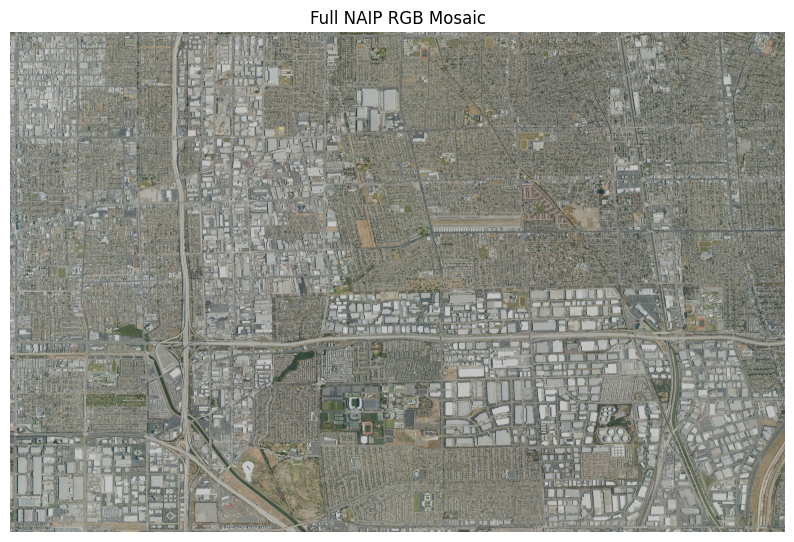

In [ ]:
larger_clip_path = "data/NAIP_Final/NAIP_AOI_Large.tif"

with rasterio.open(larger_clip_path) as src:
    # read the 3 visible bands
    rgb = src.read([1, 2, 3])

    fig, ax = plt.subplots(figsize=(10, 10))
    show(rgb, transform=src.transform, ax=ax)
    ax.set_title("Full NAIP RGB Mosaic")
    ax.axis("off")

## Preparing the Image for Segmentation

*Note: We did not re-run the following chunks for this final markdown since we only need to pre-process the data once.*

To prepare the full-scale image for the following steps, we undertook the following preprocessing steps:

- **Reprojection**: Reprojecting the full-scale image to EPSG:3857 (Web Mercator) to align with the similar tiling system that GeoDeep was trained on.
- **Division**: We divided the image into four equal regions (NE, NW, SE, SW) in order to modularize the later tiling and segmentation process, and split up the computational workload. Another benefit of performing division by zones is that it as the zones feature distinct urban typology, we can further evaluate prediction accuracy across zones for both approaches.
- **Tiling**: Finally, we tiled the full-scale mosaic image into 512 x 512 px tiles. Similar to the previous step, this modularize the segmentation process and redistribute the wordload, adding more efficiency to our analysis.

### Reproject Full-Scale Image to Web Mercator (EPSG:3857)

In [ ]:
#larger_rgb_output_path = "data/NAIP_Final/NAIP_Large_Reprojected.tif"

# target CRS
#target_crs = "EPSG:3857"

#with rasterio.open(larger_clip_path) as src:
    #transform, width, height = calculate_default_transform(
        #src.crs, target_crs, src.width, src.height, *src.bounds
    #)

    # copy & update profile for reprojection
    #profile = src.profile.copy()
    #profile.update({
        #"crs": target_crs,
        #"transform": transform,
        #"width": width,
        #"height": height,
        #"tiled": True,
        #"compress": "deflate",
        #"blockxsize": 256,
        #"blockysize": 256
   #})

    # write out the reprojected GeoTIFF
   # with rasterio.open(larger_rgb_output_path, "w", **profile) as dst:
        #for i in range(1, src.count + 1):
            #reproject(
                #source=rasterio.band(src, i),
                #destination=rasterio.band(dst, i),
                #src_transform=src.transform,
                #src_crs=src.crs,
                #dst_transform=transform,
                #dst_crs=target_crs,
                #resampling=Resampling.bilinear
            #)

#print("Reprojected full NAIP to EPSG:3857 and saved to:", larger_rgb_output_path)

### Divide Full-Scale Region into 4 different zones

In [ ]:
#region_out_dir = os.path.abspath("data/NAIP_Final/regions")
#os.makedirs(region_out_dir, exist_ok=True)

#with rasterio.open(larger_rgb_output_path) as src:
    #meta = src.meta.copy()
    #n_cols, n_rows = src.width, src.height
    #dtype = src.dtypes[0]
    #bands = src.count

    # Calculate half-size for 2x2 split
    #half_cols = n_cols // 2
    #half_rows = n_rows // 2

    # Loop over 2 rows and 2 columns
    #for row in range(2):
        #for col in range(2):
            #left = col * half_cols
            #top = row * half_rows

            # For edge tiles, ensure no data is lost due to rounding
            #width = half_cols if col < 1 else n_cols - left
            #height = half_rows if row < 1 else n_rows - top

            #window = Window(left, top, width, height)
            #transform = rasterio.windows.transform(window, src.transform)

            #data = src.read(window=window)

            #tile_meta = meta.copy()
            #tile_meta.update({
                #"height": height,
                #"width": width,
                #"transform": transform
            #})

            #out_path = os.path.join(region_out_dir, f"tile_{row}_{col}.tif")
            #with rasterio.open(out_path, "w", **tile_meta) as dst:
                #dst.write(data)

            #print(f"Wrote {out_path}")

### Creating Tiled RGB Images for Segmentation

In [ ]:
#out_dir_base = "data/NAIP_Final/regions"
#os.makedirs(out_dir_base, exist_ok=True)

#tile_size = 512

# Loop through each of the 4 region-level tiles
#for row in range(2):
    #for col in range(2):
        #tile_name = f"tile_{row}_{col}"
        #input_tile_path = os.path.join(region_out_dir, f"{tile_name}.tif")
        #output_subdir = os.path.join(out_dir_base, tile_name)
        #os.makedirs(output_subdir, exist_ok=True)

        #with rasterio.open(input_tile_path) as src:
            #meta = src.meta.copy()
            #n_cols, n_rows = src.width, src.height
            #dtype = src.dtypes[0]
            #bands = src.count

            #for top in range(0, n_rows, tile_size):
                #for left in range(0, n_cols, tile_size):
                    #w = min(tile_size, n_cols - left)
                    #h = min(tile_size, n_rows - top)
                    #window = Window(left, top, w, h)
                    #transform = rasterio.windows.transform(window, src.transform)

                    # Read the window of data
                    #data = src.read(window=window)

                    # Pad if smaller than tile_size
                    #if w == tile_size and h == tile_size:
                        #out_data = data
                    #else:
                        #out_data = np.zeros((bands, tile_size, tile_size), dtype=dtype)
                        #out_data[:, :h, :w] = data

                    #tile_meta = meta.copy()
                    #tile_meta.update({
                        #"height": tile_size,
                        #"width": tile_size,
                        #"transform": transform
                    #})

                    #out_path = os.path.join(output_subdir, f"tile_{top}_{left}.tif")
                    #with rasterio.open(out_path, "w", **tile_meta) as dst:
                        #dst.write(out_data)

                    #print(f"Wrote {out_path}")

Wrote data/NAIP_Final/regions\tile_0_0\tile_0_0.tif
Wrote data/NAIP_Final/regions\tile_0_0\tile_0_512.tif
Wrote data/NAIP_Final/regions\tile_0_0\tile_0_1024.tif
Wrote data/NAIP_Final/regions\tile_0_0\tile_0_1536.tif
Wrote data/NAIP_Final/regions\tile_0_0\tile_0_2048.tif
Wrote data/NAIP_Final/regions\tile_0_0\tile_0_2560.tif
Wrote data/NAIP_Final/regions\tile_0_0\tile_0_3072.tif
Wrote data/NAIP_Final/regions\tile_0_0\tile_0_3584.tif
Wrote data/NAIP_Final/regions\tile_0_0\tile_0_4096.tif
Wrote data/NAIP_Final/regions\tile_0_0\tile_0_4608.tif
Wrote data/NAIP_Final/regions\tile_0_0\tile_0_5120.tif
Wrote data/NAIP_Final/regions\tile_0_0\tile_0_5632.tif
Wrote data/NAIP_Final/regions\tile_0_0\tile_512_0.tif
Wrote data/NAIP_Final/regions\tile_0_0\tile_512_512.tif
Wrote data/NAIP_Final/regions\tile_0_0\tile_512_1024.tif
Wrote data/NAIP_Final/regions\tile_0_0\tile_512_1536.tif
Wrote data/NAIP_Final/regions\tile_0_0\tile_512_2048.tif
Wrote data/NAIP_Final/regions\tile_0_0\tile_512_2560.tif
Wrote 

## Prepare OSM Labels as the Ground Truth

We further downloaded and prepared OpenStreetMap (OSM) labels attached to all buildings classified as "warehouse", "industrial", and "factory" in the AOI. These OSM labels will serve as ground truths to be compared against in our evaluation step.

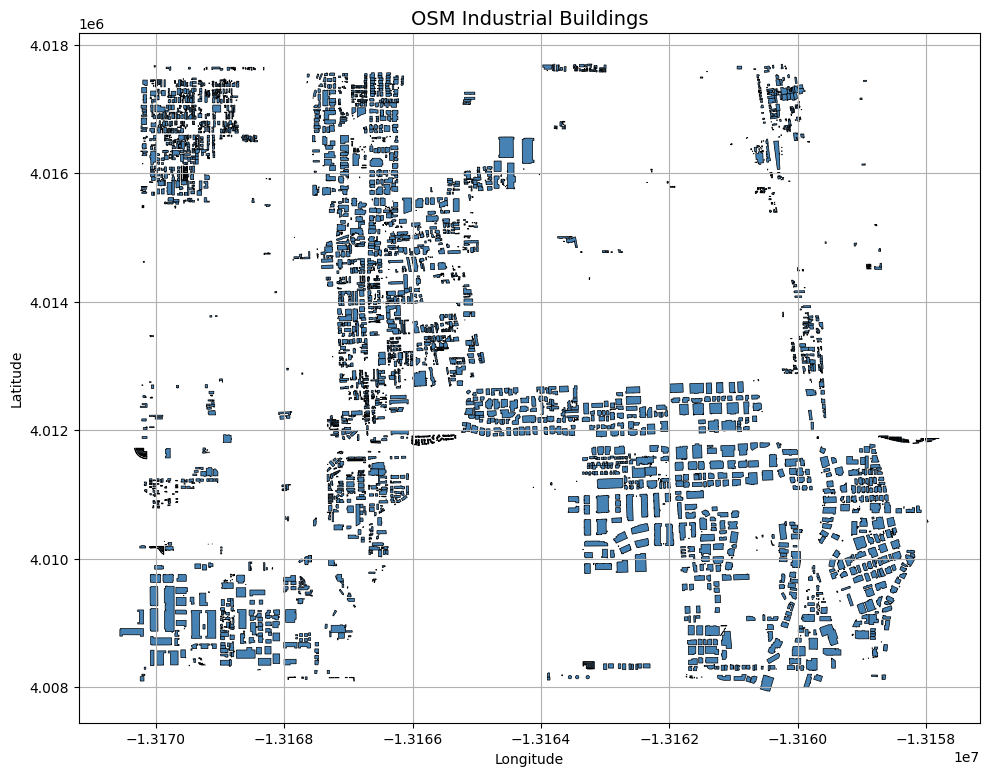

In [ ]:
bbox = (-118.31, 33.846, -118.20, 33.917)
tags = {"building": ["warehouse", "industrial", "factory"]}

crs = "EPSG:3857"

try:
    gdf_osm = features.features_from_bbox(bbox, tags)
    gdf_osm = gdf_osm.to_crs(crs)
    gdf_osm = gdf_osm[gdf_osm.geometry.type.isin(["Polygon", "MultiPolygon"])]
    gdf_osm = gdf_osm[~gdf_osm.geometry.is_empty & gdf_osm.geometry.is_valid]
    gdf_osm = gdf_osm[["geometry"]].copy()
    gdf_osm["label"] = "osm_industrial"
except Exception as e:
    print(f"OSM fetch failed: {e}")
    gdf_osm = gpd.GeoDataFrame(columns=["geometry", "label"], crs=crs)



if not gdf_osm.empty:
    fig, ax = plt.subplots(figsize=(10, 10))
    gdf_osm.plot(ax=ax, color="steelblue", edgecolor="black", linewidth=0.5)
    ax.set_title("OSM Industrial Buildings", fontsize=14)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
#save_path = "/content/drive/MyDrive/final/data/osm/osm_industrial.geojson"
#os.makedirs(os.path.dirname(save_path), exist_ok=True)

#gdf_osm.to_file(save_path, driver="GeoJSON")
#print("Wrote OSM industrial footprints to:", save_path)

NameError: name 'gdf_osm' is not defined

## Approach 1: Segmentation Using GeoDeep + Shape Detection

Our Approach 1 utilizes the GeoDeep library with shape detection (filtering by minimum area and compactness, binary erosion, and dilation) to segment and detect industrial assets in the area. The method is more computationally efficient.

### Creating Segmented Building Masks by Region

We first used GeoDeep's pretrained building segmentation model to create a building mask for each of the tiles created. As the visualization indicates, GeoDeep has detailedly segmented the buildings footprints at relatively high accuracy.

**Segmentation for Region 1 (tile_0_0)**

In [ ]:
tile_dir1 = "/content/drive/MyDrive/final/data/NAIP_Final/regions/tile_0_0"
mask_dir1 = "/content/drive/MyDrive/final/data/NAIP_Final/regions/tile_0_0/masks"
os.makedirs(mask_dir1, exist_ok=True)

# Batch‐size
batch_size = 4

# Loop & segment
for fname in sorted(os.listdir(tile_dir1)):
    if not fname.lower().endswith(".tif"):
        continue

    tile_path = os.path.join(tile_dir1, fname)
    out_name  = fname.replace(".tif", "_mask.tif")
    mask_path = os.path.join(mask_dir1, out_name)

    # segment buildings
    building_mask = segment(
        tile_path,
        "buildings"
    )

    # save the mask raster
    save_mask_to_raster(
        tile_path,       # use the tile’s georeference
        building_mask,
        mask_path
    )
    print(f"→ Wrote mask for {fname} to {mask_path}")

/content/drive/MyDrive/final/data/NAIP_Final/regions/tile_0_0/tile_0_0.tif is not tiled. I/O performance will be affected. Consider adding tiles.


→ Wrote mask for tile_0_0.tif to /content/drive/MyDrive/final/data/NAIP_Final/regions/tile_0_0/masks/tile_0_0_mask.tif


/content/drive/MyDrive/final/data/NAIP_Final/regions/tile_0_0/tile_0_1024.tif is not tiled. I/O performance will be affected. Consider adding tiles.


→ Wrote mask for tile_0_1024.tif to /content/drive/MyDrive/final/data/NAIP_Final/regions/tile_0_0/masks/tile_0_1024_mask.tif


/content/drive/MyDrive/final/data/NAIP_Final/regions/tile_0_0/tile_0_1536.tif is not tiled. I/O performance will be affected. Consider adding tiles.


...

→ Wrote mask for tile_1024_5120.tif to /content/drive/MyDrive/final/data/NAIP_Final/regions/tile_0_0/masks/tile_1024_5120_mask.tif


/content/drive/MyDrive/final/data/NAIP_Final/regions/tile_0_0/tile_1024_5632.tif is not tiled. I/O performance will be affected. Consider adding tiles.


→ Wrote mask for tile_1024_5632.tif to /content/drive/MyDrive/final/data/NAIP_Final/regions/tile_0_0/masks/tile_1024_5632_mask.tif


/content/drive/MyDrive/final/data/NAIP_Final/regions/tile_0_0/tile_1536_0.tif is not tiled. I/O performance will be affected. Consider adding tiles.


KeyboardInterrupt: 

Apr 27: We still need to run segmentation for three remainder regions

**Segmentation for Region 2 (tile_0_1)**

In [ ]:
tile_dir2 = "data/NAIP_Final/regions/tile_0_1"
mask_dir2 = "data/NAIP_Final/regions/tile_0_1/masks"
os.makedirs(mask_dir2, exist_ok=True)

# Batch‐size
batch_size = 4

# Loop & segment
for fname in sorted(os.listdir(tile_dir2)):
    if not fname.lower().endswith(".tif"):
        continue

    tile_path = os.path.join(tile_dir2, fname)
    out_name  = fname.replace(".tif", "_mask.tif")
    mask_path = os.path.join(mask_dir2, out_name)

    # segment buildings
    building_mask = segment(
        tile_path,
        "buildings"
    )

    # save the mask raster
    save_mask_to_raster(
        tile_path,
        building_mask,
        mask_path
    )
    print(f"→ Wrote mask for {fname} to {mask_path}")


data/NAIP_Final/regions/tile_0_1\tile_0_0.tif is not tiled. I/O performance will be affected. Consider adding tiles.


→ Wrote mask for tile_0_0.tif to data/NAIP_Final/regions/tile_0_1/masks\tile_0_0_mask.tif



data/NAIP_Final/regions/tile_0_1\tile_0_1024.tif is not tiled. I/O performance will be affected. Consider adding tiles.


→ Wrote mask for tile_0_1024.tif to data/NAIP_Final/regions/tile_0_1/masks\tile_0_1024_mask.tif



data/NAIP_Final/regions/tile_0_1\tile_0_1536.tif is not tiled. I/O performance will be affected. Consider adding tiles.


...

→ Wrote mask for tile_512_512.tif to data/NAIP_Final/regions/tile_0_1/masks\tile_512_512_mask.tif



data/NAIP_Final/regions/tile_0_1\tile_512_5120.tif is not tiled. I/O performance will be affected. Consider adding tiles.


→ Wrote mask for tile_512_5120.tif to data/NAIP_Final/regions/tile_0_1/masks\tile_512_5120_mask.tif



data/NAIP_Final/regions/tile_0_1\tile_512_5632.tif is not tiled. I/O performance will be affected. Consider adding tiles.


→ Wrote mask for tile_512_5632.tif to data/NAIP_Final/regions/tile_0_1/masks\tile_512_5632_mask.tif


**Segmentation for Region 3 (tile_1_0)**

In [ ]:
tile_dir3 = "data/NAIP_Final/regions/tile_1_0"
mask_dir3 = "data/NAIP_Final/regions/tile_1_0/masks"
os.makedirs(mask_dir3, exist_ok=True)

# Batch‐size
batch_size = 4

# Loop & segment
for fname in sorted(os.listdir(tile_dir3)):
    if not fname.lower().endswith(".tif"):
        continue

    tile_path = os.path.join(tile_dir3, fname)
    out_name  = fname.replace(".tif", "_mask.tif")
    mask_path = os.path.join(mask_dir3, out_name)

    # segment buildings
    building_mask = segment(
        tile_path,
        "buildings"
    )

    # save the mask raster
    save_mask_to_raster(
        tile_path,
        building_mask,
        mask_path
    )
    print(f"→ Wrote mask for {fname} to {mask_path}")


data/NAIP_Final/regions/tile_1_0\tile_0_0.tif is not tiled. I/O performance will be affected. Consider adding tiles.


→ Wrote mask for tile_0_0.tif to data/NAIP_Final/regions/tile_1_0/masks\tile_0_0_mask.tif



data/NAIP_Final/regions/tile_1_0\tile_0_1024.tif is not tiled. I/O performance will be affected. Consider adding tiles.


→ Wrote mask for tile_0_1024.tif to data/NAIP_Final/regions/tile_1_0/masks\tile_0_1024_mask.tif



data/NAIP_Final/regions/tile_1_0\tile_0_1536.tif is not tiled. I/O performance will be affected. Consider adding tiles.


...

→ Wrote mask for tile_512_512.tif to data/NAIP_Final/regions/tile_1_0/masks\tile_512_512_mask.tif



data/NAIP_Final/regions/tile_1_0\tile_512_5120.tif is not tiled. I/O performance will be affected. Consider adding tiles.


→ Wrote mask for tile_512_5120.tif to data/NAIP_Final/regions/tile_1_0/masks\tile_512_5120_mask.tif



data/NAIP_Final/regions/tile_1_0\tile_512_5632.tif is not tiled. I/O performance will be affected. Consider adding tiles.


→ Wrote mask for tile_512_5632.tif to data/NAIP_Final/regions/tile_1_0/masks\tile_512_5632_mask.tif


**Segmentation for Region 4 (tile_1_1)**

In [ ]:
tile_dir4 = "data/NAIP_Final/regions/tile_1_1"
mask_dir4 = "data/NAIP_Final/regions/tile_1_1/masks"
os.makedirs(mask_dir4, exist_ok=True)

# Batch‐size
batch_size = 4

# Loop & segment
for fname in sorted(os.listdir(tile_dir4)):
    if not fname.lower().endswith(".tif"):
        continue

    tile_path = os.path.join(tile_dir4, fname)
    out_name  = fname.replace(".tif", "_mask.tif")
    mask_path = os.path.join(mask_dir4, out_name)

    # segment buildings
    building_mask = segment(
        tile_path,
        "buildings"
    )

    # save the mask raster
    save_mask_to_raster(
        tile_path,
        building_mask,
        mask_path
    )
    print(f"→ Wrote mask for {fname} to {mask_path}")


data/NAIP_Final/regions/tile_1_1\tile_0_0.tif is not tiled. I/O performance will be affected. Consider adding tiles.


→ Wrote mask for tile_0_0.tif to data/NAIP_Final/regions/tile_1_1/masks\tile_0_0_mask.tif



data/NAIP_Final/regions/tile_1_1\tile_0_1024.tif is not tiled. I/O performance will be affected. Consider adding tiles.


→ Wrote mask for tile_0_1024.tif to data/NAIP_Final/regions/tile_1_1/masks\tile_0_1024_mask.tif



data/NAIP_Final/regions/tile_1_1\tile_0_1536.tif is not tiled. I/O performance will be affected. Consider adding tiles.


...

→ Wrote mask for tile_512_512.tif to data/NAIP_Final/regions/tile_1_1/masks\tile_512_512_mask.tif



data/NAIP_Final/regions/tile_1_1\tile_512_5120.tif is not tiled. I/O performance will be affected. Consider adding tiles.


→ Wrote mask for tile_512_5120.tif to data/NAIP_Final/regions/tile_1_1/masks\tile_512_5120_mask.tif



data/NAIP_Final/regions/tile_1_1\tile_512_5632.tif is not tiled. I/O performance will be affected. Consider adding tiles.


→ Wrote mask for tile_512_5632.tif to data/NAIP_Final/regions/tile_1_1/masks\tile_512_5632_mask.tif


**Visualize the before mask and after segmentation mask for one tile**

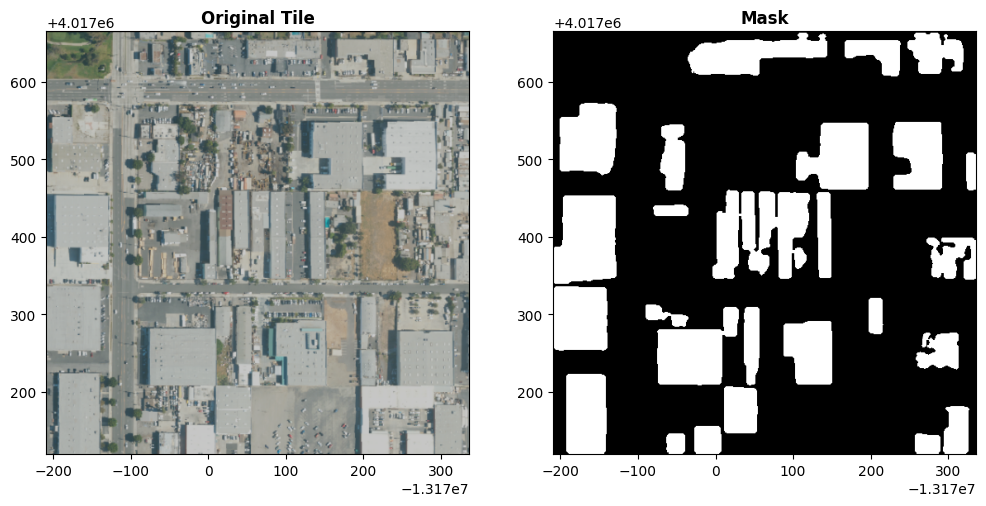

In [ ]:
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show

# Paths to the before (original tile) and after (mask) images
tile_path = "/content/drive/MyDrive/final/data/NAIP_Final/regions/tile_0_0/tile_0_0.tif"
mask_path = "/content/drive/MyDrive/final/data/NAIP_Final/regions/tile_0_0/masks/tile_0_0_mask.tif"


# Function to display the before and after images side-by-side
def visualize_before_after(tile_path, mask_path):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    with rasterio.open(tile_path) as src:
        rgb = src.read([1, 2, 3])  # Assuming RGB bands
        show(rgb, transform=src.transform, ax=axes[0], title='Original Tile')

    with rasterio.open(mask_path) as mask_src:
        mask = mask_src.read(1)
        show(mask, transform=mask_src.transform, ax=axes[1], cmap='gray', title='Mask')


    plt.show()

# Call the function to visualize the images
visualize_before_after(tile_path, mask_path)

### Perform Shape Detection

We then utilizes a computational efficient method to perform shape detection over the building mask using geometric filters and morphological operations.

The code operates by labelling connected components in the segmentation mask and identify likely industrial structures ("candidates") based on spatial characteristics. It first filters out small or irregular regions by applying thresholds on area (minimum 300 square meters) and compactness at the mask resolution of 0.5 meters (output characteristic of GeoDeep masks). Then, we applied binary erosion to break apart dense clusters, followed by dilation to recover core industrial areas that exceed a secondary area threshold of 600 square meters. We save the output tiles as two-band raster: the first band corresponds to g the original segmentation mask, and the other second indicate industrial classification based on shape detection.

Then, we extracted vector geometries from each band of the raster, and stored the polygons in separate GeoDataFrames. In order to compare the detection results with ground truths (OSM labels), we loaded industrial labels from the previously prepared OSM data. Together, we merged all geometries into a single GeoDataFrame, ensuring consistent spatial reference. The combined dataset is then exported and stored to allow for evaluation and comparision.

#### Create a Mosaic Mask File to Avoid Unintentional Chipping of Buildings

To avoid accidentally chipping off the edge of the building during the tiling process, we combined all building mask tiles to create a mosaic image for more accurate shape detection results.

In [ ]:
#mask_dirs = [
    #Path("data/NAIP_Final/regions/tile_0_0/masks"),
    #Path("data/NAIP_Final/regions/tile_0_1/masks"),
    #Path("data/NAIP_Final/regions/tile_1_0/masks"),
    #Path("data/NAIP_Final/regions/tile_1_1/masks")
#]

#mask_files = []
#for d in mask_dirs:
    #mask_files.extend(sorted(d.glob("*.tif")))

#srcs = [rio_open(f) for f in mask_files]

#mosaic, out_transform = merge(srcs)

#out_meta = srcs[0].meta.copy()
#out_meta.update({
    #"height": mosaic.shape[1],
    #"width": mosaic.shape[2],
    #"transform": out_transform,
    #"count": 1  # Assuming single-band masks
#})

#merged_mask_path = Path("data/NAIP_Final/merged_mask.tif")
#with rio_open(merged_mask_path, "w", **out_meta) as dest:
    #dest.write(mosaic[0], 1)

#for s in srcs:
    #s.close()

#print(f"Merged mask saved to: {merged_mask_path}")

Merged mask saved to: data\NAIP_Final\merged_mask.tif


#### Perform Shape Detection Using Minimum Area and Erosion

In [ ]:
merged_mask_path = Path("data/NAIP_Final/merged_mask.tif")

resolution = 0.5
min_area_m2 = 300
min_area_px = int(min_area_m2 / (resolution ** 2))
erod_area_m2 = 600
erod_area_px = int(erod_area_m2 / (resolution ** 2))

with rasterio.open(merged_mask_path) as src:
    mask = src.read(1)
    meta = src.meta.copy()

# Ensure binary mask
mask = (mask > 0).astype(np.uint8)

# Primary shape detection
labeled_mask = label(mask, connectivity=2)
industrial_mask = np.zeros_like(mask, dtype=np.uint8)

for region in regionprops(labeled_mask):
    area = region.area
    if area < min_area_px:
        continue
    perimeter = region.perimeter
    compactness = perimeter ** 2 / (area + 1e-6)
    if compactness < 20:
        industrial_mask[labeled_mask == region.label] = 1

# Erosion & expansion recovery
erod_core = 7
dilate_kernel = disk(erod_core)
eroded_region = binary_erosion(mask, dilate_kernel)

erod_labeled_mask = label(eroded_region, connectivity=2)

for region in regionprops(erod_labeled_mask):
    if region.area < erod_area_px:
        continue
    coords = region.coords
    region_mask = np.zeros_like(mask, dtype=bool)
    region_mask[tuple(coords.T)] = True
    expanded_region = binary_dilation(region_mask, dilate_kernel)
    industrial_mask[expanded_region] = 1

meta.update({
    "count": 2,
    "dtype": "uint8"
})

labeled_mask_path = merged_mask_path.with_name(merged_mask_path.stem + "_industrial.tif")

with rasterio.open(labeled_mask_path, "w", **meta) as dst:
    dst.write(mask, 1)
    dst.write(industrial_mask, 2)

print(f"Saved: {labeled_mask_path.name}")

Saved: merged_mask_industrial.tif


**Visualize the Shape Detected Result from Merged Image**

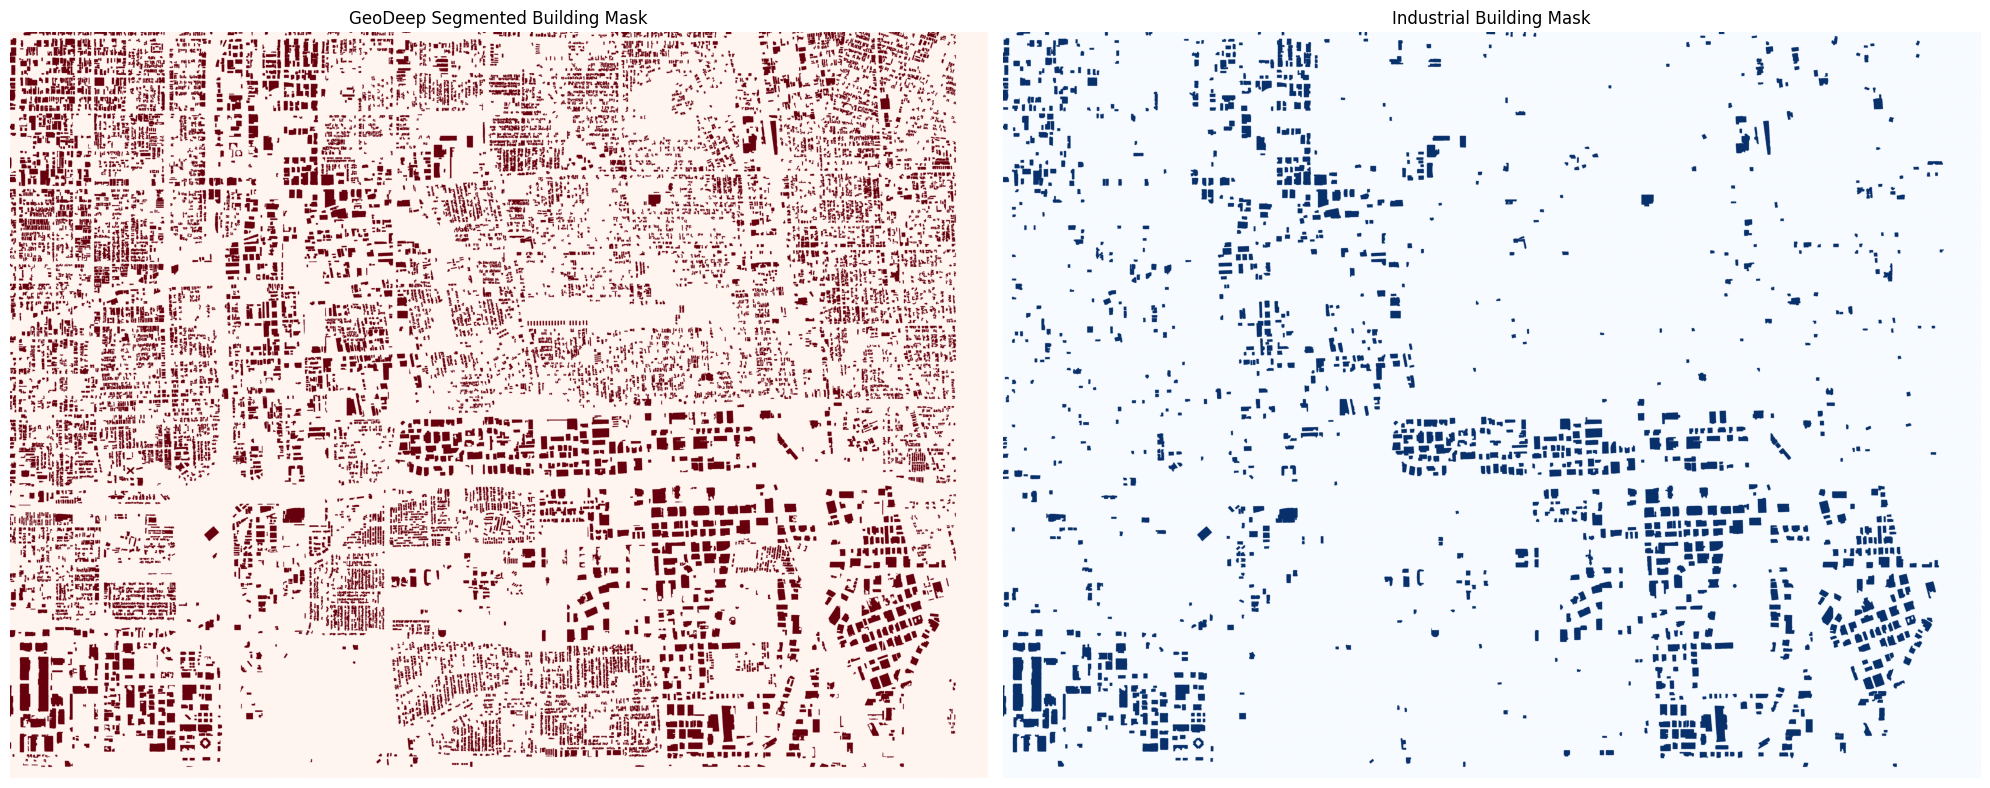

In [ ]:
labeled_mask_file = "data/NAIP_Final/merged_mask_industrial.tif"

# Read both bands
with rasterio.open(labeled_mask_file) as src:
    building_mask = src.read(1)
    industrial_mask = src.read(2)

fig, axs = plt.subplots(1, 2, figsize=(20, 10))  # Wider and taller

axs[0].imshow(building_mask, cmap='Reds')
axs[0].set_title("GeoDeep Segmented Building Mask")
axs[0].axis("off")

axs[1].imshow(industrial_mask, cmap='Blues')
axs[1].set_title("Industrial Building Mask")
axs[1].axis("off")

plt.tight_layout()
plt.show()

#### Append the OSM Labels to Approach 1 Generated Results

In [ ]:
labeled_mask_path = Path("data/NAIP_Final/merged_mask_industrial.tif")

with rasterio.open(labeled_mask_path) as src:
    building_mask = src.read(1)
    industrial_mask = src.read(2)
    transform = src.transform
    crs = src.crs

building_geom = []
for g, v in shapes(building_mask, mask=building_mask > 0, transform=transform):
    if v == 1:
        try:
            building_geom.append({"geometry": shape(g), "label": "geodeep"})
        except:
            continue

gdf_building = gpd.GeoDataFrame(building_geom, crs=crs, geometry="geometry")

gdf_industrial = []
for g, v in shapes(industrial_mask, mask=industrial_mask > 0, transform=transform):
    if v == 1:
        try:
            gdf_industrial.append({"geometry": shape(g), "label": "filtered"})
        except:
            continue

gdf_industrial = gpd.GeoDataFrame(gdf_industrial, crs=crs, geometry="geometry")

In [ ]:
# Load OSM GeoDataFrame
gdf_osm = gpd.read_file("data/osm/osm_industrial.geojson")

# Compile the two GeoDataFrames
gdf_all = pd.concat([gdf_building, gdf_industrial, gdf_osm], ignore_index=True)
gdf_all = gpd.GeoDataFrame(gdf_all, crs=crs, geometry="geometry")

gdf_all.to_file("data/NAIP_Final/gdf_all_output.geojson", driver="GeoJSON")

### Approach 1 Evaluation

For Approach 1, because the method is highly reliant on the pixelated information in each of the building masks, we evaluated the approach's performance over both number of buildings predicted (polygons) as well as pixels predicted. We used precision, recall, and F1 score as metrics, which respectively measures:

- precision: how many of the features labeled as industrial by shape detection are correct
- recall: how many of the actual industrial features were successfully detected
- F1 Score: harmonic mean of predicion and recall

#### Overall Detection Performance

This section captures the overall prediction results for the entire AOI (four regions combined).

**Evaluating Polygon (Single Building Footprint) Prediction Performance**

Comparing the shape-detected industrial buildings against OSM-labeled industrial footprints, the method identified 1460 buildings as industrial. Of these, 937 were correctly labeled (true positives) and 523 were misclassified (false positives), resulting in a precision of 0.64. This suggests that, under current parameters, the model is beginning to mislabel other similarly sized structures—such as strip malls—as industrial. However, the recall is low at 0.24, indicating that a large portion of the 2,897 actual industrial buildings, likely including many small machine shops, remain undetected. As a result, the overall F1 score is 0.35, reflecting an imbalanced performance that favors precision over coverage.

In [ ]:
# Separate each group
gdf_filtered = gdf_all[gdf_all["label"] == "filtered"].copy()
gdf_osm = gdf_all[gdf_all["label"] == "osm_industrial"].copy()

# Compute spatial intersection
if not gdf_osm.empty and not gdf_filtered.empty:
    gdf_filtered["matched_osm"] = gdf_filtered.geometry.apply(
        lambda geom: gdf_osm.intersects(geom).any()
    )
    gdf_osm["matched_filtered"] = gdf_osm.geometry.apply(
        lambda geom: gdf_filtered.intersects(geom).any()
    )

    # Confusion matrix logic
    tp = gdf_filtered["matched_osm"].sum()
    fp = (~gdf_filtered["matched_osm"]).sum()
    fn = (~gdf_osm["matched_filtered"]).sum()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print("Spatial Confusion Matrix (Polygons):")
    print(f"True Positives (filtered ∩ osm):   {tp}")
    print(f"False Positives (filtered only):   {fp}")
    print(f"False Negatives (osm only):        {fn}")
    print("\nMetrics:")
    print(f"Precision: {precision:.2f}")
    print(f"Recall:    {recall:.2f}")
    print(f"F1 Score:  {f1:.2f}")
else:
    print("No valid geometries in one or both datasets — can't compute confusion matrix.")

Spatial Confusion Matrix (Polygons):
True Positives (filtered ∩ osm):   937
False Positives (filtered only):   523
False Negatives (osm only):        2897

Metrics:
Precision: 0.64
Recall:    0.24
F1 Score:  0.35


**Evaluating Raster Prediction Performance**

At the pixel level, the shape detection approach achieved a precision of 0.70, indicating that 70% of pixels labeled as industrial by the shape detection method were correct, while 30% were false positives. On the other hand, the recall value of 0.50 shows that half of all actual industrial pixels were successfully detected. The F1 score has also increased to 0.58, reflecting a more balanced performance at the pixel level.

In [ ]:
from rasterio.features import rasterize
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# Filter geometries by label
gdf_filtered = gdf_all[gdf_all["label"] == "filtered"]
gdf_osm = gdf_all[gdf_all["label"] == "osm_industrial"]

# Get raster dimensions and transform
with rasterio.open(merged_mask_path) as src:
    transform = src.transform
    height = src.height
    width = src.width

# Rasterize each group
filtered_mask_raster = rasterize(
    [(geom, 1) for geom in gdf_filtered.geometry],
    out_shape=(height, width),
    transform=transform,
    fill=0,
    dtype="uint8"
)

osm_mask_raster = rasterize(
    [(geom, 1) for geom in gdf_osm.geometry],
    out_shape=(height, width),
    transform=transform,
    fill=0,
    dtype="uint8"
)

# Flatten masks
y_true = osm_mask_raster.flatten()
y_pred = filtered_mask_raster.flatten()

# Compute pixel-level confusion matrix and scores
cm = confusion_matrix(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print("\nSpatial Confusion Matrix (Pixels):")
print(cm)
print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1 Score:  {f1:.2f}")


Spatial Confusion Matrix (Pixels):
[[95245301  2260586]
 [ 5296422  5246245]]
Precision: 0.70
Recall:    0.50
F1 Score:  0.58


#### Detection Performance By Region

Finally, we evaluated the performance of Approach 1 across four identically sized regions of the AOI. The four regions are respectively characterized by:

- NW: mixed industrial and residential developments
- NE: relatively sparse industrial developments featuring small industrial assets, and dense residential developments
- SW: mixed industrial and residential developments, in combination with large park areas and other amenities (E.g. school)
- SE: dense industrial developments with relatively sparse residential

**Divide Up Four Zones**

In [ ]:
aoi_large_bounds = [-118.31, 33.846, -118.20, 33.917]

# Project to EPSG:3857
project = pyproj.Transformer.from_crs(4326, 3857, always_xy=True).transform
minx, miny = project(aoi_large_bounds[0], aoi_large_bounds[1])
maxx, maxy = project(aoi_large_bounds[2], aoi_large_bounds[3])

# Calculate midpoints
mid_x = (minx + maxx) / 2
mid_y = (miny + maxy) / 2

# Build zone boxes
zones = {
    "NW": box(minx, mid_y, mid_x, maxy),
    "NE": box(mid_x, mid_y, maxx, maxy),
    "SW": box(minx, miny, mid_x, mid_y),
    "SE": box(mid_x, miny, maxx, mid_y),
}

**Evaluating Polygon (Single Building Footprint) Prediction Performance**

Comparing results of polygon detection, the approach's performance varies significantly across zones. The SE zone (zone with heaviest industrial development) shows the strongest results, with a precision of 0.823, recall of 0.492, and an F1 score of 0.616, indicating effective detection with relatively few false positives, although approximately half of the industrial assets were still missed.

In contrast, the NE zone (zone with most residential developments mixed with small-scale industrial assets) performs the worst, with a precision of just 0.200, a recall of 0.087, and an F1 score of 0.121, suggesting widespread under-detection and frequent misclassification.

Both NW and SW zones show moderate precision (about 0.6) but suffer from low recall (about 0.2) and F1 scores below 0.3.

These discrepancies suggest that the detection is geographically uneven, and the same set of shape detection parameter produce varied results even around the same AOI.

In [ ]:
zone_stats_polygon = []

for name, zone_geom in zones.items():
    filtered_zone = gdf_filtered[gdf_filtered.intersects(zone_geom)].copy()
    osm_zone      = gdf_osm[gdf_osm.intersects(zone_geom)].copy()

    if not filtered_zone.empty and not osm_zone.empty:
        filtered_zone["matched_osm"] = filtered_zone.geometry.apply(
            lambda geom: osm_zone.intersects(geom).any()
        )
        osm_zone["matched_filtered"] = osm_zone.geometry.apply(
            lambda geom: filtered_zone.intersects(geom).any()
        )

        tp = filtered_zone["matched_osm"].sum()
        fp = (~filtered_zone["matched_osm"]).sum()
        fn = (~osm_zone["matched_filtered"]).sum()

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1        = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    else:
        tp = fp = fn = precision = recall = f1 = 0

    zone_stats_polygon.append({
        "zone": name,
        "true_positives": int(tp),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "precision": round(precision, 3),
        "recall": round(recall, 3),
        "f1_score": round(f1, 3)
    })

zone_df_polygon = pd.DataFrame(zone_stats_polygon)
print(zone_df_polygon.to_string(index=False))

zone  true_positives  false_positives  false_negatives  precision  recall  f1_score
  NW             331              187             1448      0.639   0.186     0.288
  NE              30              120              314      0.200   0.087     0.121
  SW             190              138              753      0.579   0.201     0.299
  SE             391               84              403      0.823   0.492     0.616


**Evaluating Raster Prediction Performance**

Variation in detection performance across regions (zones) also prevail at the pixel level. Similar to polyon results, the SE zone (area with densest industrial development in the AOI) demonstrates the strongest results with a precision of 0.833, recall of 0.567, and an F1 score of 0.675, indicating both high accuracy and solid coverage. The performance of our method in NW and SW regions have also improved throughout all metrics; in particular, results in the SW zone yields a precision of 0.652 and a recall of 0.498, achieving an F1 score of 0.565.

Nonetheless, performance remain poor for the NE section, with a 0.241 prediction, 0.288 recall, and an F1 score of only 0.262, suggesting both high false positives and poor coverage.

Overall, the first approach revealed high sensitivity to local contextual and typological features. While the approach is more computational efficient and friendly for local planners, it requires localized knowledge of industrial building attributes in the area to be more accurately deployed. On the other hand, this approach is challeneged with generalizability concerns, and is not suited for predicting across wider area.

In [ ]:
with rasterio.open(merged_mask_path) as src:
    transform = src.transform
    height = src.height
    width = src.width

# Compute metrics for each region
zone_stats = []

for name, zone_geom in zones.items():
    # Clip geometries by zone
    filtered_zone = gdf_filtered[gdf_filtered.intersects(zone_geom)]
    osm_zone      = gdf_osm[gdf_osm.intersects(zone_geom)]

    # Rasterize both
    pred_raster = rasterize(
        [(geom, 1) for geom in filtered_zone.geometry],
        out_shape=(height, width),
        transform=transform,
        fill=0,
        dtype="uint8"
    )

    true_raster = rasterize(
        [(geom, 1) for geom in osm_zone.geometry],
        out_shape=(height, width),
        transform=transform,
        fill=0,
        dtype="uint8"
    )

    # Flatten for comparison
    y_pred = pred_raster.flatten()
    y_true = true_raster.flatten()

    # Compute scores
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)

    zone_stats.append({
        "zone": name,
        "true_count": int((y_true == 1).sum()),
        "pred_count": int((y_pred == 1).sum()),
        "precision": round(precision, 3),
        "recall": round(recall, 3),
        "f1_score": round(f1, 3),
        "confusion_matrix": cm.tolist()
    })

zone_df = pd.DataFrame(zone_stats)
print(zone_df.to_string(index=False))

zone  true_count  pred_count  precision  recall  f1_score                          confusion_matrix
  NW     3296072     2133023      0.642   0.415     0.504 [[103988512, 763970], [1927019, 1369053]]
  NE      414095      493447      0.241   0.288     0.262   [[107260077, 374382], [295030, 119065]]
  SW     2386221     1820755      0.652   0.498     0.565 [[105029086, 633247], [1198713, 1187508]]
  SE     4581260     3118517      0.833   0.567     0.675 [[102946301, 520993], [1983736, 2597524]]


## Approach 2: Deep Learning

As our first approach of performing shape detection over GeoDeep pre-segmatation masks yield poor performance, we further trained a deep-learning segmenation model as an alternative approach.

In Approach 2, we leveraged high‐resolution NAIP aerial imagery as the model’s input and use OpenStreetMap building footprints as our ground‐truth labels. By preprocessing and aligning these datasets to create paired input–output samples, we train a deep learning segmentation model to automatically extract accurate building outlines from the raw imagery.

We chose U-Net because its encoder–decoder architecture captures both broad context and fine details, while skip connections preserve sharp roof boundaries and improve localization of small structures. After aligning and normalizing the imagery and masks into paired training samples, we train the network to automatically extract precise building outlines from raw aerial data.

### Data Preparation

#### Clip and Rasterize the OSM Data

First, we iterated over each 512×512 NAIP image tile (not the segmentation mask), reads its geospatial metadata, and then clips the industrial building polygons from the OSM data to that tile’s bounding box.

This step also converts each clipped OSM footprint into a binary mask, pixels inside industrial building polygons are set to 1 and everything else to 0, while preserving the original tile’s size and geospatial transform. It then saves that mask as a single-band GeoTIFF whose name appends _osm_mask.tif to the input tile (e.g. tile_512_5632.tif → tile_512_5632_osm_mask.tif), ensuring alignment between imagery and ground-truth labels.

In [ ]:
import os
import glob
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from shapely.geometry import box

# Load OSM footprints
gdf_osm = gpd.read_file("data/osm/osm_industrial.geojson")

# Find all your 512×512 tiles on disk
base = "/content/drive/MyDrive/final/data/NAIP_Final/regions"
all_tiles = glob.glob(os.path.join(base, "**", "*.tif"), recursive=True)
tile_paths = [p for p in all_tiles if "_osm_mask" not in p]
if not tile_paths:
    raise RuntimeError(f"No .tif tiles found under {base}")

print(f"Found {len(tile_paths)} tiles, processing...")

for tile_path in sorted(tile_paths):
    fname    = os.path.basename(tile_path)
    tile_dir = os.path.dirname(tile_path)
    mask_dir = os.path.join(tile_dir, "osm_masks")
    os.makedirs(mask_dir, exist_ok=True)

    out_mask = os.path.join(mask_dir, fname.replace(".tif", "_osm_mask.tif"))
    print(f"\n→ processing {fname}")
    print(f"   writing mask to: {mask_dir}/")

    # Read tile metadata & bounds
    with rasterio.open(tile_path) as src:
        meta      = src.meta.copy()
        transform = src.transform
        width, height = src.width, src.height
        bounds    = src.bounds

    # Clip OSM footprints to this tile’s bbox
    tile_box = gpd.GeoSeries([box(*bounds)], crs=meta["crs"])
    gdf_sub  = gpd.clip(gdf_osm, tile_box)

    # Rasterize the clipped polys → 0/1 mask
    mask = rasterize(
        [(geom, 1) for geom in gdf_sub.geometry],
        out_shape=(height, width),
        transform=transform,
        fill=0,
        dtype="uint8",
    )

    # Write a single‐band GeoTIFF mask
    meta.update({"count": 1, "dtype": "uint8"})
    with rasterio.open(out_mask, "w", **meta) as dst:
        dst.write(mask, 1)

    print(f"[OSM] wrote mask → {out_mask}")

print("\nDone. Each region now has its own osm_masks/ folder.")


Found 868 tiles, processing...

→ processing tile_0_0.tif
   writing mask to: /content/drive/MyDrive/final/data/NAIP_Final/regions/osm_masks/
[OSM] wrote mask → /content/drive/MyDrive/final/data/NAIP_Final/regions/osm_masks/tile_0_0_osm_mask.tif

→ processing tile_0_0_mask.tif
   writing mask to: /content/drive/MyDrive/final/data/NAIP_Final/regions/tile_0_0/masks/osm_masks/
[OSM] wrote mask → /content/drive/MyDrive/final/data/NAIP_Final/regions/tile_0_0/masks/osm_masks/tile_0_0_mask_osm_mask.tif

→ processing tile_0_1024_mask.tif
   writing mask to: /content/drive/MyDrive/final/data/NAIP_Final/regions/tile_0_0/masks/osm_masks/
[OSM] wrote mask → /content/drive/MyDrive/final/data/NAIP_Final/regions/tile_0_0/masks/osm_masks/tile_0_1024_mask_osm_mask.tif

→ processing tile_0_1536_mask.tif
   writing mask to: /content/drive/MyDrive/final/data/NAIP_Final/regions/tile_0_0/masks/osm_masks/
[OSM] wrote mask → /content/drive/MyDrive/final/data/NAIP_Final/regions/tile_0_0/masks/osm_masks/tile_0_

#### Assembling *Image–Segmentation–OSM* Mask Triplets

After generating the osm masks, we built a clean list of “image + ground truth + OSM label” triplets that can be feeded directly into training or evaluation pipeline

In [ ]:
import os, glob

# base folder containing your four region sub-folders (tile_0_0, tile_0_1, etc.)
base_dir = "data/NAIP_Final/regions"

# find every region folder
region_dirs = sorted(
    d for d in glob.glob(os.path.join(base_dir, "tile_*_*"))
    if os.path.isdir(d)
)

# collect triplets: (tile, segment-mask, osm-mask)
dataset = []
for region in region_dirs:
    tile_dir = region
    seg_dir  = os.path.join(region, "masks")
    osm_dir  = os.path.join(region, "osm_masks")

    # all the NAIP tile files in this region (skip existing mask files)
    for tile_path in sorted(glob.glob(os.path.join(tile_dir, "*.tif"))):
        base = os.path.splitext(os.path.basename(tile_path))[0]
        # only raw tiles (not *_mask.tif or *_osm_mask.tif)
        if base.endswith("_mask") or base.endswith("_osm_mask"):
            continue

        seg_path = os.path.join(seg_dir, f"{base}_mask.tif")
        osm_path = os.path.join(osm_dir, f"{base}_osm_mask.tif")

        # only keep it if both masks exist
        if os.path.exists(seg_path) and os.path.exists(osm_path):
            dataset.append((tile_path, seg_path, osm_path))

print(f"Found {len(dataset)} samples across {len(region_dirs)} regions.")
# dataset is now a list of (tile, geo-deep-mask, osm-mask) tuples



Found 432 samples across 4 regions.


#### Discovering Tile–Mask Pairs & Loading into Arrays

Then, we defined a function that navigated through each region folder to match every raw NAIP tile with its corresponding OSM‐derived mask, producing a list of tile_path, mask_path pairs. It then read those pairs into memory—loading each RGB tile as a float32 array normalized to [0,1] with shape (H,W,3) and each binary mask as a float32 array of shape (H,W,1)—and stacked them into two NumPy arrays (X and Y) ready for training or evaluation.

In [ ]:
import os
import glob
import numpy as np
import rasterio
from sklearn.model_selection import train_test_split

# -----------------------------------------------------------------------------
# 1) DISCOVER TILE + OSM MASK PAIRS
# -----------------------------------------------------------------------------
def discover_tile_mask_pairs(regions_dir):
    """
    Walk each subfolder named 'tile_r_c' under regions_dir.
    For each raw tile 'tile_r_c.tif', look for an OSM mask
    in '.../osm_masks/tile_r_c_osm_mask.tif'. Return list of tuples.
    """
    pairs = []
    pattern = os.path.join(regions_dir, "tile_*_*")
    for region in sorted(glob.glob(pattern)):
        osm_folder = os.path.join(region, "osm_masks")
        for tile_path in sorted(glob.glob(os.path.join(region, "*.tif"))):
            name = os.path.splitext(os.path.basename(tile_path))[0]
            # skip any masks in the root
            if name.endswith("_mask") or name.endswith("_osm_mask"):
                continue

            osm_path = os.path.join(osm_folder, f"{name}_osm_mask.tif")
            if os.path.isfile(osm_path):
                pairs.append((tile_path, osm_path))

    return pairs

# -----------------------------------------------------------------------------
# 2) LOAD IMAGES & MASKS INTO NUMPY ARRAYS
# -----------------------------------------------------------------------------
def load_tile_mask_arrays(pairs):
    """
    Given a list of (tile_path, osm_mask_path), read:
      - tile_path → 3-band array normalized to [0,1], shape (H,W,3)
      - osm_mask_path → binary mask, shape (H,W,1)
    Returns two arrays: X=(N,H,W,3), Y=(N,H,W,1)
    """
    X, Y = [], []
    for tile_path, mask_path in pairs:
        # RGB image
        with rasterio.open(tile_path) as src:
            rgb = src.read([1,2,3]).astype(np.float32) / 255.0  # (3,H,W)
        # OSM mask
        with rasterio.open(mask_path) as src:
            m = src.read(1).astype(np.float32)[None, :, :]      # (1,H,W)

        # move channels last
        X.append(np.moveaxis(rgb, 0, -1))  # (H,W,3)
        Y.append(np.moveaxis(m,   0, -1))  # (H,W,1)

    return np.stack(X, axis=0), np.stack(Y, axis=0)



Discovered 432 tile–mask pairs.
Split into → Train: 345, Val: 43, Test: 44
Array shapes: X_train (345, 512, 512, 3), Y_train (345, 512, 512, 1); X_val   (43, 512, 512, 3),   Y_val   (43, 512, 512, 1); X_test  (44, 512, 512, 3),  Y_test  (44, 512, 512, 1)


### Model Training

#### Split and Load Dataset

We splitted the data into 80 % training, 10 % validation, and 10 % test sets.

In [ ]:
# -----------------------------------------------------------------------------
# 3) MAIN: DISCOVER, SPLIT, LOAD
# -----------------------------------------------------------------------------
if __name__ == "__main__":
    regions_dir = "data/NAIP_Final/regions"
    pairs = discover_tile_mask_pairs(regions_dir)
    print(f"Discovered {len(pairs)} tile–mask pairs.")

    # 80% train, 10% val, 10% test
    train_pairs, temp_pairs = train_test_split(
        pairs, test_size=0.2, random_state=42, shuffle=True
    )
    val_pairs, test_pairs = train_test_split(
        temp_pairs, test_size=0.5, random_state=42, shuffle=True
    )

    print(f"Split into → Train: {len(train_pairs)}, Val: {len(val_pairs)}, Test: {len(test_pairs)}")

    # load NumPy arrays
    X_train, Y_train = load_tile_mask_arrays(train_pairs)
    X_val,   Y_val   = load_tile_mask_arrays(val_pairs)
    X_test,  Y_test  = load_tile_mask_arrays(test_pairs)

    print(
        "Array shapes:",
        f"X_train {X_train.shape}, Y_train {Y_train.shape};",
        f"X_val   {X_val.shape},   Y_val   {Y_val.shape};",
        f"X_test  {X_test.shape},  Y_test  {Y_test.shape}"
    )


**Visualize the X-Y Pairs**

X represents the NAIP aerial image, while Y stands for its corresponding OSM mask.

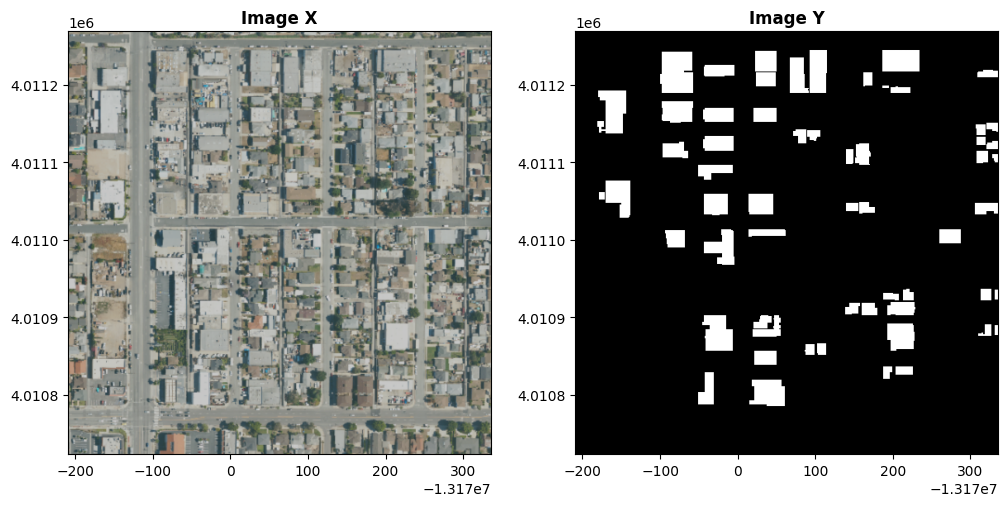

In [ ]:

# Paths to the images
X_path = "data/NAIP_Final/regions/tile_1_0/tile_1536_0.tif"
Y_path = "data/NAIP_Final/regions/tile_1_0/osm_masks/tile_1536_0_osm_mask.tif"


def visualize_images(X_path, Y_path):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    try:
        with rasterio.open(X_path) as src:
            X = src.read([1, 2, 3])  # Assuming RGB bands
            show(X, transform=src.transform, ax=axes[0], title='Image X')
    except Exception as e:
        print(f"Error opening or visualizing X: {e}")
        axes[0].set_title("Error visualizing X")


    try:
        with rasterio.open(Y_path) as src:
            Y = src.read(1)  # Assuming a single-band mask
            show(Y, transform=src.transform, cmap='gray', ax=axes[1], title='Image Y')
    except Exception as e:
        print(f"Error opening or visualizing Y: {e}")
        axes[1].set_title("Error visualizing Y")

    plt.show()

visualize_images(X_path, Y_path)


#### Model Training & Overal Performance Metrics

Over 20 epochs, the model’s training accuracy rose from 0.679 to 0.982 and its validation accuracy from 0.601 to 0.954; on the test set, it achieved 0.956. 

In [ ]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import rasterio
import numpy as np
import segmentation_models_pytorch as smp
from torch.optim import Adam

# 1) Custom Dataset that remembers paths
class NAIPOSMDataset(Dataset):
    def __init__(self, samples):
        """
        samples: list of (tile_path, osm_mask_path)
        """
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        tile_path, mask_path = self.samples[idx]

        # Load RGB tile
        with rasterio.open(tile_path) as src:
            img = src.read([1,2,3]).astype("float32") / 255.0  # (3,H,W)
        # Load OSM mask
        with rasterio.open(mask_path) as src:
            m = src.read(1).astype("float32")[None,:,:]       # (1,H,W)

        # move channels last → (H,W,C)
        x = np.moveaxis(img, 0, -1)
        y = np.moveaxis(m,   0, -1)

        # convert to tensors, move channels first → (C,H,W)
        xt = torch.from_numpy(x).permute(2,0,1).float()
        yt = torch.from_numpy(y).permute(2,0,1).float()

        return xt, yt, tile_path, mask_path

# 2) Build datasets & loaders
def make_loader(sample_list, batch_size=8, shuffle=False):
    ds = NAIPOSMDataset(sample_list)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_dl = make_loader(train_samps, batch_size=8, shuffle=True)
val_dl   = make_loader(val_samps,   batch_size=8, shuffle=False)
test_dl  = make_loader(test_samps,  batch_size=8, shuffle=False)

# 3) Define model, optimizer, metrics (as before)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
).to(device)
optimizer = Adam(model.parameters(), lr=1e-4)

def iou_coef(pred, target, eps=1e-6):
    pb = (pred > 0.5).float()
    inter = (pb * target).sum((1,2,3))
    union = ((pb + target) > 0).float().sum((1,2,3))
    return ((inter+eps)/(union+eps)).mean().item()

def pixel_accuracy(pred, target, thresh=0.5):
    pb = (pred > thresh).float()
    return pb.eq(target).float().mean().item()

# 4) Training loop with path‐checking
epochs = 20
for epoch in range(1, epochs+1):
    model.train()
    running = {"loss":0, "iou":0, "acc":0}

    for batch_idx, (xb, yb, xp, yp) in enumerate(train_dl):
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss   = F.binary_cross_entropy_with_logits(logits, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        preds = torch.sigmoid(logits)
        running["loss"] += loss.item()
        running["iou"]  += iou_coef(preds, yb)
        running["acc"]  += pixel_accuracy(preds, yb)

        # Print the file paths for the very first batch of every epoch:
        if batch_idx == 0:
            print(f"\n[Epoch {epoch}]  SAMPLE PATHS (first batch):")
            for i in range(min(3, xb.size(0))):
                print(f"  X[{i}]: {xp[i]}")
                print(f"  Y[{i}]: {yp[i]}")
            print("-"*60)

    # summarize train epoch
    n = len(train_dl)
    print(f"Epoch {epoch:02d} TRAIN → "
          f"loss {running['loss']/n:.4f}, "
          f"iou {running['iou']/n:.3f}, "
          f"acc {running['acc']/n:.3f}")

    # validation (similarly, but without path printing)
    model.eval()
    val_metrics = {"loss":0, "iou":0, "acc":0}
    with torch.no_grad():
        for xb, yb, _, _ in val_dl:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            val_metrics["loss"] += F.binary_cross_entropy_with_logits(logits, yb).item()
            preds = torch.sigmoid(logits)
            val_metrics["iou"]  += iou_coef(preds, yb)
            val_metrics["acc"]  += pixel_accuracy(preds, yb)

    m = len(val_dl)
    print(f"           VAL   → "
          f"loss {(val_metrics['loss']/m):.4f}, "
          f"iou {(val_metrics['iou']/m):.3f}, "
          f"acc {(val_metrics['acc']/m):.3f}\n")





[Epoch 1]  SAMPLE PATHS (first batch):
  X[0]: data/NAIP_Final/regions/tile_1_1/tile_512_3072.tif
  Y[0]: data/NAIP_Final/regions/tile_1_1/osm_masks/tile_512_3072_osm_mask.tif
  X[1]: data/NAIP_Final/regions/tile_0_0/tile_4096_2048.tif
  Y[1]: data/NAIP_Final/regions/tile_0_0/osm_masks/tile_4096_2048_osm_mask.tif
  X[2]: data/NAIP_Final/regions/tile_0_1/tile_512_3584.tif
  Y[2]: data/NAIP_Final/regions/tile_0_1/osm_masks/tile_512_3584_osm_mask.tif
------------------------------------------------------------
Epoch 01 TRAIN → loss 0.5892, iou 0.131, acc 0.679
           VAL   → loss 0.6038, iou 0.153, acc 0.601


[Epoch 2]  SAMPLE PATHS (first batch):
  X[0]: data/NAIP_Final/regions/tile_0_1/tile_3072_2048.tif
  Y[0]: data/NAIP_Final/regions/tile_0_1/osm_masks/tile_3072_2048_osm_mask.tif
  X[1]: data/NAIP_Final/regions/tile_1_0/tile_3584_4608.tif
  Y[1]: data/NAIP_Final/regions/tile_1_0/osm_masks/tile_3584_4608_osm_mask.tif
  X[2]: data/NAIP_Final/regions/tile_1_1/tile_4096_4096.tif
  Y

In [ ]:
# Test evaluation
model.eval()
test_metrics = {"loss":0, "iou":0, "acc":0}
with torch.no_grad():
    for xb, yb, _, _ in test_dl:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        test_metrics["loss"] += F.binary_cross_entropy_with_logits(logits, yb).item()
        preds = torch.sigmoid(logits)
        test_metrics["iou"]  += iou_coef(preds, yb)
        test_metrics["acc"]  += pixel_accuracy(preds, yb)

m = len(test_dl)
print(f"TEST → loss {(test_metrics['loss']/m):.4f}, "
      f"iou {(test_metrics['iou']/m):.3f}, "
      f"acc {(test_metrics['acc']/m):.3f}")

#### Model Evaluation by Region

Across the four test regions, the model consistently delivers very high pixel‐wise accuracy (≥ 0.969) and respectable segmentation quality, with IoU scores ranging from 0.640 to 0.782. The lower IoU in tile_0_0 (0.640, loss 0.116) versus the peak in tile_1_1 (0.782, loss 0.109) suggests some sensitivity to local building patterns. Overall, these results demonstrate strong generalization but also highlight region‐specific gaps. Nonetheless, the results are much more promising as compared to Approach 1, reflecting more nuanced patterns that model is picking up from the R, G, B bands.

In [ ]:
import os
import glob
import numpy as np
import rasterio
import torch
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

# 1) Discover raw-tile + osm-mask pairs
def discover_tile_osm_pairs(base_dir):
    pairs = []
    for region in sorted(glob.glob(os.path.join(base_dir, "tile_*_*"))):
        osm_dir = os.path.join(region, "osm_masks")
        for tile_path in sorted(glob.glob(os.path.join(region, "*.tif"))):
            name = os.path.splitext(os.path.basename(tile_path))[0]
            # skip any existing mask files
            if name.endswith("_mask") or name.endswith("_osm_mask"):
                continue
            osm_path = os.path.join(osm_dir, f"{name}_osm_mask.tif")
            if os.path.isfile(osm_path):
                pairs.append((tile_path, osm_path))
    return pairs

# 2) Loader: turn (tile, osm) into X,Y arrays
def load_dataset(samples):
    X, Y = [], []
    for tile_path, osm_path in samples:
        with rasterio.open(tile_path) as src:
            img = src.read([1,2,3]).astype("float32") / 255.0   # (3,H,W)
        with rasterio.open(osm_path) as src:
            osm = src.read(1).astype("float32")[None,:,:]      # (1,H,W)

        # move channel last
        X.append(np.moveaxis(img, 0, -1))  # (H,W,3)
        Y.append(np.moveaxis(osm, 0, -1))  # (H,W,1)

    return np.stack(X), np.stack(Y)

# 3) Wrap to DataLoader
def make_loader(X, Y, batch_size=8):
    Xt = torch.from_numpy(X).permute(0,3,1,2).float()  # (N,3,H,W)
    Yt = torch.from_numpy(Y).permute(0,3,1,2).float()  # (N,1,H,W)
    return DataLoader(TensorDataset(Xt, Yt), batch_size=batch_size, shuffle=False)

# --- main evaluation on tile_0_0 ---
base_dir     = "data/NAIP_Final/regions"
all_pairs    = discover_tile_osm_pairs(base_dir)

# filter to region tile_0_0
region = "tile_0_0"
region_dir = os.path.join(base_dir, region)
test_pairs = [p for p in all_pairs if os.path.dirname(p[0]) == region_dir]

if not test_pairs:
    raise RuntimeError(f"No samples found in {region_dir!r}")

print(f"Evaluating on {len(test_pairs)} tiles from {region}")

# load data & loader
X_test, Y_test = load_dataset(test_pairs)
test_dl        = make_loader(X_test, Y_test, batch_size=8)

# assume model & device are defined
model.eval()
tot_loss = tot_iou = tot_acc = 0.0

with torch.no_grad():
    for xb, yb in test_dl:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss   = F.binary_cross_entropy_with_logits(logits, yb)

        preds       = torch.sigmoid(logits)
        tot_loss   += loss.item()
        tot_iou    += iou_coef(preds, yb)
        tot_acc    += pixel_accuracy(preds, yb)

n = len(test_dl)
print(f"\nResults for region '{region}':")
print(f"  Loss: {tot_loss/n:.4f}")
print(f"  IOU : {tot_iou/n:.3f}")
print(f"  Acc : {tot_acc/n:.3f}")



Evaluating on 108 tiles from tile_0_0

Results for region 'tile_0_0':
  Loss: 0.1159
  IOU : 0.640
  Acc : 0.969


In [ ]:
import os
import glob
import numpy as np
import rasterio
import torch
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

# 1) Discover raw-tile + osm-mask pairs
def discover_tile_osm_pairs(base_dir):
    pairs = []
    for region in sorted(glob.glob(os.path.join(base_dir, "tile_*_*"))):
        osm_dir = os.path.join(region, "osm_masks")
        for tile_path in sorted(glob.glob(os.path.join(region, "*.tif"))):
            name = os.path.splitext(os.path.basename(tile_path))[0]
            # skip any existing mask files
            if name.endswith("_mask") or name.endswith("_osm_mask"):
                continue
            osm_path = os.path.join(osm_dir, f"{name}_osm_mask.tif")
            if os.path.isfile(osm_path):
                pairs.append((tile_path, osm_path))
    return pairs

# 2) Loader: turn (tile, osm) into X,Y arrays
def load_dataset(samples):
    X, Y = [], []
    for tile_path, osm_path in samples:
        with rasterio.open(tile_path) as src:
            img = src.read([1,2,3]).astype("float32") / 255.0   # (3,H,W)
        with rasterio.open(osm_path) as src:
            osm = src.read(1).astype("float32")[None,:,:]      # (1,H,W)

        # move channel last
        X.append(np.moveaxis(img, 0, -1))  # (H,W,3)
        Y.append(np.moveaxis(osm, 0, -1))  # (H,W,1)

    return np.stack(X), np.stack(Y)

# 3) Wrap to DataLoader
def make_loader(X, Y, batch_size=8):
    Xt = torch.from_numpy(X).permute(0,3,1,2).float()  # (N,3,H,W)
    Yt = torch.from_numpy(Y).permute(0,3,1,2).float()  # (N,1,H,W)
    return DataLoader(TensorDataset(Xt, Yt), batch_size=batch_size, shuffle=False)

# --- main evaluation on tile_0_0 ---
base_dir     = "data/NAIP_Final/regions"
all_pairs    = discover_tile_osm_pairs(base_dir)

# filter to region tile_0_1
region = "tile_0_1"
region_dir = os.path.join(base_dir, region)
test_pairs = [p for p in all_pairs if os.path.dirname(p[0]) == region_dir]

if not test_pairs:
    raise RuntimeError(f"No samples found in {region_dir!r}")

print(f"Evaluating on {len(test_pairs)} tiles from {region}")

# load data & loader
X_test, Y_test = load_dataset(test_pairs)
test_dl        = make_loader(X_test, Y_test, batch_size=8)

# assume model & device are defined
model.eval()
tot_loss = tot_iou = tot_acc = 0.0

with torch.no_grad():
    for xb, yb in test_dl:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss   = F.binary_cross_entropy_with_logits(logits, yb)

        preds       = torch.sigmoid(logits)
        tot_loss   += loss.item()
        tot_iou    += iou_coef(preds, yb)
        tot_acc    += pixel_accuracy(preds, yb)

n = len(test_dl)
print(f"\nResults for region '{region}':")
print(f"  Loss: {tot_loss/n:.4f}")
print(f"  IOU : {tot_iou/n:.3f}")
print(f"  Acc : {tot_acc/n:.3f}")


Evaluating on 108 tiles from tile_0_1

Results for region 'tile_0_1':
  Loss: 0.0420
  IOU : 0.685
  Acc : 0.994


In [ ]:
import os
import glob
import numpy as np
import rasterio
import torch
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

# 1) Discover raw-tile + osm-mask pairs
def discover_tile_osm_pairs(base_dir):
    pairs = []
    for region in sorted(glob.glob(os.path.join(base_dir, "tile_*_*"))):
        osm_dir = os.path.join(region, "osm_masks")
        for tile_path in sorted(glob.glob(os.path.join(region, "*.tif"))):
            name = os.path.splitext(os.path.basename(tile_path))[0]
            # skip any existing mask files
            if name.endswith("_mask") or name.endswith("_osm_mask"):
                continue
            osm_path = os.path.join(osm_dir, f"{name}_osm_mask.tif")
            if os.path.isfile(osm_path):
                pairs.append((tile_path, osm_path))
    return pairs

# 2) Loader: turn (tile, osm) into X,Y arrays
def load_dataset(samples):
    X, Y = [], []
    for tile_path, osm_path in samples:
        with rasterio.open(tile_path) as src:
            img = src.read([1,2,3]).astype("float32") / 255.0   # (3,H,W)
        with rasterio.open(osm_path) as src:
            osm = src.read(1).astype("float32")[None,:,:]      # (1,H,W)

        # move channel last
        X.append(np.moveaxis(img, 0, -1))  # (H,W,3)
        Y.append(np.moveaxis(osm, 0, -1))  # (H,W,1)

    return np.stack(X), np.stack(Y)

# 3) Wrap to DataLoader
def make_loader(X, Y, batch_size=8):
    Xt = torch.from_numpy(X).permute(0,3,1,2).float()  # (N,3,H,W)
    Yt = torch.from_numpy(Y).permute(0,3,1,2).float()  # (N,1,H,W)
    return DataLoader(TensorDataset(Xt, Yt), batch_size=batch_size, shuffle=False)

# --- main evaluation on tile_0_0 ---
base_dir     = "data/NAIP_Final/regions"
all_pairs    = discover_tile_osm_pairs(base_dir)

# filter to region tile_0_1
region = "tile_1_0"
region_dir = os.path.join(base_dir, region)
test_pairs = [p for p in all_pairs if os.path.dirname(p[0]) == region_dir]

if not test_pairs:
    raise RuntimeError(f"No samples found in {region_dir!r}")

print(f"Evaluating on {len(test_pairs)} tiles from {region}")

# load data & loader
X_test, Y_test = load_dataset(test_pairs)
test_dl        = make_loader(X_test, Y_test, batch_size=8)

# assume model & device are defined
model.eval()
tot_loss = tot_iou = tot_acc = 0.0

with torch.no_grad():
    for xb, yb in test_dl:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss   = F.binary_cross_entropy_with_logits(logits, yb)

        preds       = torch.sigmoid(logits)
        tot_loss   += loss.item()
        tot_iou    += iou_coef(preds, yb)
        tot_acc    += pixel_accuracy(preds, yb)

n = len(test_dl)
print(f"\nResults for region '{region}':")
print(f"  Loss: {tot_loss/n:.4f}")
print(f"  IOU : {tot_iou/n:.3f}")
print(f"  Acc : {tot_acc/n:.3f}")

Evaluating on 108 tiles from tile_1_0

Results for region 'tile_1_0':
  Loss: 0.0955
  IOU : 0.709
  Acc : 0.977


In [ ]:
import os
import glob
import numpy as np
import rasterio
import torch
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

# 1) Discover raw-tile + osm-mask pairs
def discover_tile_osm_pairs(base_dir):
    pairs = []
    for region in sorted(glob.glob(os.path.join(base_dir, "tile_*_*"))):
        osm_dir = os.path.join(region, "osm_masks")
        for tile_path in sorted(glob.glob(os.path.join(region, "*.tif"))):
            name = os.path.splitext(os.path.basename(tile_path))[0]
            # skip any existing mask files
            if name.endswith("_mask") or name.endswith("_osm_mask"):
                continue
            osm_path = os.path.join(osm_dir, f"{name}_osm_mask.tif")
            if os.path.isfile(osm_path):
                pairs.append((tile_path, osm_path))
    return pairs

# 2) Loader: turn (tile, osm) into X,Y arrays
def load_dataset(samples):
    X, Y = [], []
    for tile_path, osm_path in samples:
        with rasterio.open(tile_path) as src:
            img = src.read([1,2,3]).astype("float32") / 255.0   # (3,H,W)
        with rasterio.open(osm_path) as src:
            osm = src.read(1).astype("float32")[None,:,:]      # (1,H,W)

        # move channel last
        X.append(np.moveaxis(img, 0, -1))  # (H,W,3)
        Y.append(np.moveaxis(osm, 0, -1))  # (H,W,1)

    return np.stack(X), np.stack(Y)

# 3) Wrap to DataLoader
def make_loader(X, Y, batch_size=8):
    Xt = torch.from_numpy(X).permute(0,3,1,2).float()  # (N,3,H,W)
    Yt = torch.from_numpy(Y).permute(0,3,1,2).float()  # (N,1,H,W)
    return DataLoader(TensorDataset(Xt, Yt), batch_size=batch_size, shuffle=False)

# --- main evaluation on tile_0_0 ---
base_dir     = "data/NAIP_Final/regions"
all_pairs    = discover_tile_osm_pairs(base_dir)

# filter to region tile_0_1
region = "tile_1_1"
region_dir = os.path.join(base_dir, region)
test_pairs = [p for p in all_pairs if os.path.dirname(p[0]) == region_dir]

if not test_pairs:
    raise RuntimeError(f"No samples found in {region_dir!r}")

print(f"Evaluating on {len(test_pairs)} tiles from {region}")

# load data & loader
X_test, Y_test = load_dataset(test_pairs)
test_dl        = make_loader(X_test, Y_test, batch_size=8)

# assume model & device are defined
model.eval()
tot_loss = tot_iou = tot_acc = 0.0

with torch.no_grad():
    for xb, yb in test_dl:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss   = F.binary_cross_entropy_with_logits(logits, yb)

        preds       = torch.sigmoid(logits)
        tot_loss   += loss.item()
        tot_iou    += iou_coef(preds, yb)
        tot_acc    += pixel_accuracy(preds, yb)

n = len(test_dl)
print(f"\nResults for region '{region}':")
print(f"  Loss: {tot_loss/n:.4f}")
print(f"  IOU : {tot_iou/n:.3f}")
print(f"  Acc : {tot_acc/n:.3f}")


Evaluating on 108 tiles from tile_1_1

Results for region 'tile_1_1':
  Loss: 0.1094
  IOU : 0.782
  Acc : 0.975


**Region-Scale Inference & Visualization**  

In the following step, we stitched all individual NAIP tiles and their OSM masks into full-region mosaics (Region 0_0 or the NW region of the AOI), then ran the trained model on each tile-sized patch to build a continuous prediction map across the entire area.

Finally, we displayed the RGB mosaic alongside the ground-truth OSM mask and the model’s predicted mask in a three-panel figure for a qualitative assessment of segmentation performance.

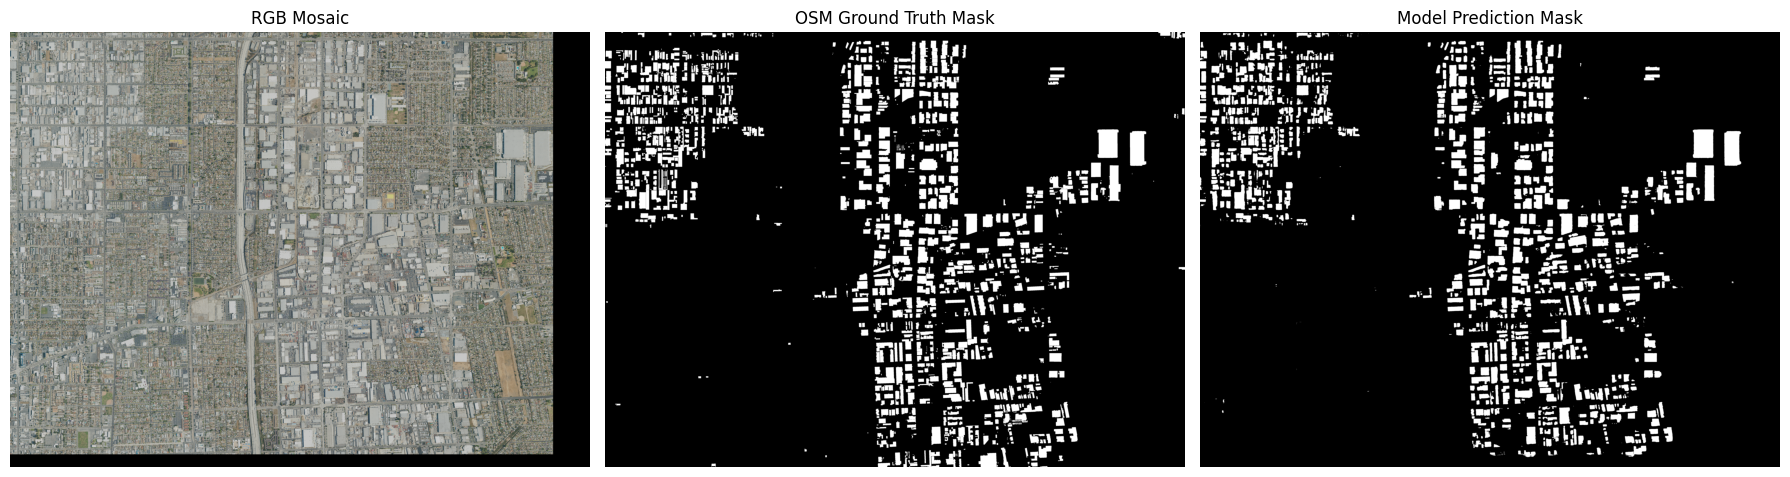

In [ ]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.merge import merge
from rasterio.windows import Window
import torch
import torch.nn.functional as F

# --- CONFIGURATION ---
base_dir   = "data/NAIP_Final/regions"
region     = "tile_0_0"
region_dir = os.path.join(base_dir, region)
tile_size = 512  # Adjust tile size as needed

# --- 1) MOSAIC INPUT AND GROUND TRUTH ---
# a) RGB mosaic (X)
tile_paths = sorted(glob.glob(os.path.join(region_dir, "*.tif")))
with rasterio.open(tile_paths[0]) as src0:
    meta0 = src0.meta.copy()
tile_ds = [rasterio.open(p) for p in tile_paths]
mosaic_rgb, mosaic_trans = merge(tile_ds)  # → (3, H, W)

# b) OSM mosaic (Y)
osm_paths = sorted(glob.glob(os.path.join(region_dir, "osm_masks", "*_osm_mask.tif")))
osm_ds    = [rasterio.open(p) for p in osm_paths]
mosaic_osm, _ = merge(osm_ds)             # → (1, H, W)

# --- 2) MODEL INFERENCE (with tiling) ---
# Initialize empty prediction array
pred_mosaic = np.zeros_like(mosaic_osm[0], dtype=np.uint8)

# Process mosaic in tiles
for y in range(0, mosaic_rgb.shape[1], tile_size):
    for x in range(0, mosaic_rgb.shape[2], tile_size):
        # Define tile window
        window = Window(x, y, tile_size, tile_size)

        # Read tile data
        tile_rgb = mosaic_rgb[:, window.row_off:window.row_off + window.height,
                               window.col_off:window.col_off + window.width]

        # Normalize and add batch dimension
        inp = torch.from_numpy(tile_rgb.astype("float32") / 255.0) \
                    .unsqueeze(0).to(device)

        # Model inference
        model.eval()
        with torch.no_grad():
            logits = model(inp)
            prob   = torch.sigmoid(logits)[0,0]
            pred_tile = (prob.cpu().numpy() > 0.5).astype(np.uint8)

        # Place prediction tile in the mosaic
        pred_mosaic[window.row_off:window.row_off + window.height,
                    window.col_off:window.col_off + window.width] = pred_tile

# --- 3) VISUALIZATION ---
# Prepare arrays
rgb_image = np.transpose(mosaic_rgb, (1, 2, 0))
gt_mask   = mosaic_osm[0]
pred_mask = pred_mosaic

# Create a row of 3 plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# RGB
axes[0].imshow(rgb_image)
axes[0].set_title("RGB Mosaic")
axes[0].axis("off")

# Ground-truth mask in B/W
axes[1].imshow(gt_mask, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("OSM Ground Truth Mask")
axes[1].axis("off")

# Prediction mask in B/W
axes[2].imshow(pred_mask, cmap="gray", vmin=0, vmax=1)
axes[2].set_title("Model Prediction Mask")
axes[2].axis("off")

plt.tight_layout()
plt.show()


Visualization shows that the model reliably captures the majority of industrial footprints defined in the OSM labels, but it misses several clusters in the southwestern quadrant, fails to detect smaller structures, and produces weaker predictions along the southern edge of the mosaic. These issues likely arise from limited multi‐scale feature representation in the decoder and border artifacts introduced by non-overlapping tile inference. In the future could integrate a feature-pyramid or attention-based module for better small‐object sensitivity, use overlapping tiles with reflective padding to reduce edge effects, and enrich the training set with augmented examples of diverse building sizes.

**Overlay against Original NAIP Imagery (NW region)**

Overlay the model’s predicted industrial‐area mask onto the original NAIP imagery, clearly highlighting detected facilities in their true geographic context.

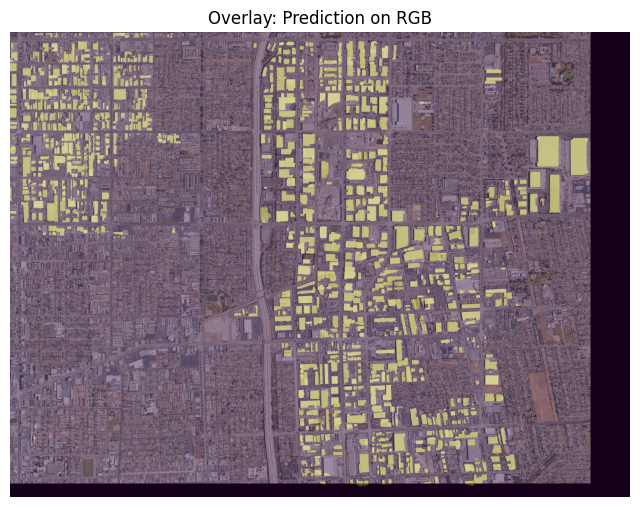

In [ ]:
plt.figure(figsize=(8, 8))
plt.imshow(rgb_image)
plt.imshow(pred_mask, alpha=0.3)   # semi-transparent overlay
plt.title("Overlay: Prediction on RGB")
plt.axis("off")
plt.show()

## Conclusion


## Conclusion


The GeoDeep + shape‐filtering pipeline offers a lightweight, CPU-only solution that quickly flags large building footprints without requiring a GPU. However, its fixed size thresholds and generic building segmentation lead to highly variable performance across distinct planning and building typologies, making it most appropriate for small, localized planning efforts rather than broad, heterogeneous regions.

By comparison, a U-Net trained end-to-end on OSM-derived industrial footprints delivers stronger overall accuracy (pixel IoU \~0.53; pixel accuracy \~0.96), recovering far more true warehouse areas while keeping false positives low. Although more computationally intensive and dependent on the completeness of OSM labels, this approach better adapts to diverse rooftop shapes and scales.

From these results, we conclude a clear trade-off: 
- GeoDeep + Shape Detection is efficient and label-agnostic but rigid
- While U-Net provides flexibility and higher recall at the cost of greater data and compute requirements.

**Next Steps**

To build a more robust detection pipeline, we recommend that future work should:

1. **Apply Localized Knowledge and Be Sensitive to Scales**: If the user opts to run Approach 1, they should strategically set up reasonable detection parameters and restrain the scale they work at, in order to take full benefit of GeoDeep.

If the user opts for Approach 2, they should:

2. **Diversify Training Data**: Incorporate imagery from multiple regions and seasons to reduce overfitting and improve generalization.
3. **Enhance Model Capacity**: Add multi‐scale feature pyramids or attention modules to better detect small and low-contrast buildings.
4. **Mitigate Edge Effects**: Use overlapping tile inference with reflective padding.
5. **Explore Instance Segmentation**: Transition to Mask R-CNN or similar to separate adjacent buildings and enable per‐footprint evaluation.
6. **Apply Post-Processing**: Use morphological filters or conditional random fields to clean spurious detections and sharpen boundaries.
7. **Implement Active Learning**: Iteratively correct OSM label errors and sample hard negatives to boost recall on challenging cases.